In this file you will have to create your own polynomial model(s). I have provided less scaffolding in this file compared to the last one as we follow mostly the same process anyway

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

For the first model you will make a simple (1 independent variable) polynomial model. The data we will use will compare height and weight in people. Below I have loaded the data for you. The rest is up to you. It would be good to plots for the data and, after you have made it, the regression line. Make sure to include testing the model at the end

In [2]:
df = pd.read_csv('data/Weight-Height Polynomial Dataset.csv')
df.head()

,Weight,Height
0,69.963210,96.644532
1,116.057145,196.156340
2,98.559515,145.862047
3,87.892679,121.157923
4,52.481491,68.971292


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  50 non-null     float64
 1   Height  50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [29]:
df = df.sort_values('Height')


X = df.iloc[:, 1:].values
y = df.iloc[:, 0:1].values

In [30]:
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

poly.fit(X_poly, y)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


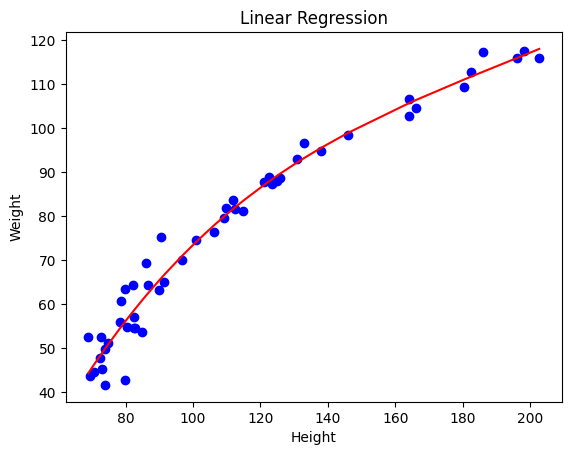

In [31]:
plt.scatter(X, y, color='blue')

plt.plot(X, poly_reg.predict(X_poly), color='red')
plt.title('Linear Regression')
plt.xlabel('Height')
plt.ylabel('Weight')

plt.show()

In [32]:
y_pred = poly_reg.predict(X_poly)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(mse)
print(r2)

15.798342133588195
0.9698171052151624


Alright, once you have finished the first model you can work on the multiple independent variable dataset.

The dataset for this one is regards sales of various products. With this dataset it would be good to only pick out columns that you think are useful to the data

In [42]:
data = pd.read_csv('data/sales_data_with_revenue.csv')
data.head()

,product_category,units_sold,price_per_unit,is_returned,sale_date,total_revenue
0,C,96,356.542747,0,2020-01-01,5178.878929
1,D,94,386.211956,1,2020-01-02,4983.644721
2,A,47,52.772188,1,2020-01-03,1146.226516
3,C,99,257.990939,0,2020-01-04,5332.891565
4,C,55,466.687028,1,2020-01-05,2269.065707


In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_category  600 non-null    str    
 1   units_sold        600 non-null    int64  
 2   price_per_unit    600 non-null    float64
 3   is_returned       600 non-null    int64  
 4   sale_date         600 non-null    str    
 5   total_revenue     600 non-null    float64
dtypes: float64(2), int64(2), str(2)
memory usage: 28.3 KB



I'm going to plot the data to see which features are actually relevant

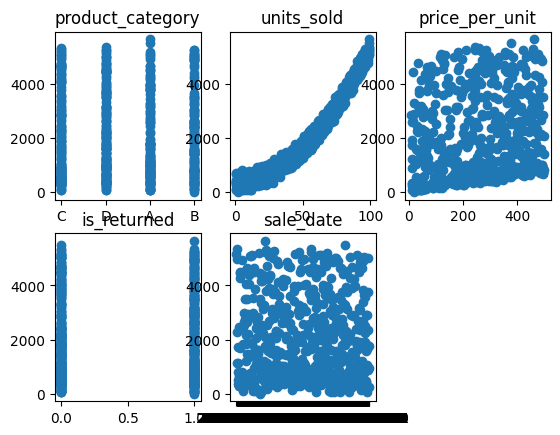

In [43]:
features = ['product_category', 'units_sold', 'price_per_unit', 'is_returned', 'sale_date']

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  plt.title(features[i])
  plt.scatter(data[col], data['total_revenue'])
plt.show()

It looks like is_returned and sale_date have little bearing on the revenue. It could be argued that product category also doesn't seem to have an impact but I'm going to leave it in just in case

I've mapped the data and set our X and y variables. I have left in the data is null method as the first time I ran this I ended up with nulls

In [44]:
data['product_category'] = data['product_category'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3})
X_2 = data[['product_category', 'units_sold', 'price_per_unit']]
y_2 = data['total_revenue']
data.isnull().sum()

product_category    0
units_sold          0
price_per_unit      0
is_returned         0
sale_date           0
total_revenue       0
dtype: int64

Let's make our data polynomial

In [45]:
poly_2 = PolynomialFeatures(degree = 3, include_bias = False)

X_2_poly = poly_2.fit_transform(X_2)

And split it into training and testing data

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X_2_poly, y_2, test_size=0.3, random_state=42)

And make and fit our model

In [47]:
poly_model = LinearRegression()
poly_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Now we can test our model on the training and testing data

In [48]:
mse_train = mean_squared_error(y_train, poly_model.predict(X_train))
r2_train = r2_score(y_train, poly_model.predict(X_train))
print(f"Mean Squared Error: {mse_train}")
print(f"R-squared: {r2_train}")

Mean Squared Error: 2217.9320859096047
R-squared: 0.9990586618775957


In [49]:
y_pred = poly_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 2491.6478319571015
R-squared: 0.9989006736700895


We can see that our r2 value is really good on both the training and testing data which is an indicator of a good model

We can make predictions using our model now. To do so we need to fit our data to be polynomial first

In [59]:
test_pred = poly_2.fit_transform([[2, 100, 100]])
prediction = poly_model.predict(test_pred)
print(prediction)

[5148.04133436]


Playing around with this we can see that while they all affect the revenue to some degree, the units sold has the biggest impact on revenue